In [ ]:
# ==============================================================================
# 1. SETUP & DATA INGESTION
# ==============================================================================

import pandas as pd
import numpy as np
import io

RANDOM_SEED = 20
np.random.seed(RANDOM_SEED)

df = pd.read_csv('mod_bank_additional_1.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [9]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
df.duplicated().sum()

np.int64(12)

In [11]:
# Remove duplicate records
df = df.drop_duplicates(keep='first').copy()

# Binary target mapping: 1 for 'yes' (subscribed), 0 for 'no'
df['target'] = df['y'].map({'yes': 1, 'no': 0})
df = df.drop(columns=['y'])

In [13]:
# Transform sentinel 999 into a binary indicator (1 = contacted before, 0 = never)
df['pdays_contacted'] = (df['pdays'] != 999).astype(int)

# Numeric predictors: EXCLUDING duration (leakage) AND pdays (sentinel)
numeric_features = [
    'age', 'campaign', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

# Categorical predictors: INCLUDING pdays_contacted
categorical_features = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome',
    'pdays_contacted'
]

X_realistic = df[numeric_features + categorical_features]
y = df['target'].values

print("=== TABLE 2 DATA AUDIT REPORT ===")
print(f"Dataset: Bank Telemarketing (Additional Full)")
print(f"Total instances (N): {len(df)}")
print(f"Features (p): {len(numeric_features) + len(categorical_features)} (8 numeric + 11 categorical, excluding duration)")
print(f"Class balance:\n{df['target'].value_counts(normalize=True).apply(lambda x: f'{x*100:.2f}%')}")
print(f"pdays == 999 (never contacted): {(df['pdays'] == 999).sum()} ({(df['pdays'] == 999).mean()*100:.2f}%)")
print(f"pdays_contacted == 1 (contacted): {(df['pdays_contacted'] == 1).sum()} ({(df['pdays_contacted'] == 1).mean()*100:.2f}%)")
print(f"Number of duplicates: {df.duplicated().sum()}")

=== TABLE 2 DATA AUDIT REPORT ===
Dataset: Bank Telemarketing (Additional Full)
Total instances (N): 41176
Features (p): 19 (8 numeric + 11 categorical, excluding duration)
Class balance:
target
0    88.73%
1    11.27%
Name: proportion, dtype: object
pdays == 999 (never contacted): 39661 (96.32%)
pdays_contacted == 1 (contacted): 1515 (3.68%)
Number of duplicates: 0


NESTED CROSS-VALIDATION ENGINE (15 OUTER EVALUATION FOLDS)

In [20]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

# Leak-free preprocessor (fits only on outer training folds)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 4 baseline estimators across 4 distinct families
base_models = {
    'Logistic_Regression': LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED
    ),
    'Decision_Tree': DecisionTreeClassifier(
        random_state=RANDOM_SEED
    ),
    'Random_Forest': RandomForestClassifier(
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    'Neural_Network_MLP': MLPClassifier(
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_SEED
    )
}

In [21]:
# Harmonized 16-configuration search spaces (equal tuning budget)
param_grids = {
    'Logistic_Regression': {
        'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0],
        'model__class_weight': [None, 'balanced']
    },
    'Decision_Tree': {
        'model__max_depth': [4, 6, 8, 12],
        'model__min_samples_split': [2, 5, 10, 20]
    },
    'Random_Forest': {
        'model__n_estimators': [100, 150, 200, 300],
        'model__max_depth': [8, 14],
        'model__min_samples_split': [5, 15]
    },
    'Neural_Network_MLP': {
        'model__hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32)],
        'model__alpha': [0.0001, 0.001, 0.01, 0.1]     # 4 * 4 = 16 configs
    }
}

outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)

raw_results = []
oof_predictions = {name: {'y_true': [], 'y_pred': []} for name in base_models.keys()}
outer_fold_idx = 0
total_start_time = time.time()

STARTING NESTED CROSS-VALIDATION EXPERIMENT (15 OUTER EVALUATION FOLDS)

In [ ]:
print("==========================================================================")
print("  STARTING NESTED CROSS-VALIDATION EXPERIMENT (15 OUTER EVALUATION FOLDS) ")
print("==========================================================================")

for train_idx, test_idx in outer_cv.split(X_realistic, y):
    outer_fold_idx += 1
    repeat_num = ((outer_fold_idx - 1) // 5) + 1
    fold_num = ((outer_fold_idx - 1) % 5) + 1

    print(f"\n>>> Running Outer Fold {outer_fold_idx:02d}/15 (Repeat {repeat_num}, Split {fold_num})")

    X_train_fold, X_test_fold = X_realistic.iloc[train_idx], X_realistic.iloc[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    for model_name, base_estimator in base_models.items():
        t_start_train = time.time()

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', base_estimator)
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            cv=3,
            scoring='roc_auc',
            n_jobs=-1
        )

        grid_search.fit(X_train_fold, y_train_fold)
        train_duration = time.time() - t_start_train

        best_pipeline = grid_search.best_estimator_

        t_start_pred = time.time()
        y_pred = best_pipeline.predict(X_test_fold)
        pred_duration = time.time() - t_start_pred
        latency_ms_per_sample = (pred_duration / len(X_test_fold)) * 1000.0

        if hasattr(best_pipeline, "predict_proba"):
            y_scores = best_pipeline.predict_proba(X_test_fold)[:, 1]
        else:
            y_scores = best_pipeline.decision_function(X_test_fold)

        oof_predictions[model_name]['y_true'].extend(y_test_fold)
        oof_predictions[model_name]['y_pred'].extend(y_pred)

        auc_score = roc_auc_score(y_test_fold, y_scores)
        pr_auc_score = average_precision_score(y_test_fold, y_scores)
        macro_f1 = f1_score(y_test_fold, y_pred, average='macro')
        bal_acc = balanced_accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        raw_results.append({
            'outer_fold': outer_fold_idx,
            'repeat': repeat_num,
            'split': fold_num,
            'algorithm': model_name,
            'roc_auc': auc_score,
            'pr_auc': pr_auc_score,
            'macro_f1': macro_f1,
            'balanced_accuracy': bal_acc,
            'mcc': mcc,
            'train_time_sec': train_duration,
            'latency_ms_sample': latency_ms_per_sample,
            'best_params': str(grid_search.best_params_)
        })

        print(f"  [{model_name:<22}] ROC-AUC: {auc_score:.4f} | PR-AUC: {pr_auc_score:.4f} | F1: {macro_f1:.4f} | Train: {train_duration:5.1f}s | Latency: {latency_ms_per_sample:.4f}ms")

# Export all fold evaluations to CSV
df_raw = pd.DataFrame(raw_results)
df_raw.to_csv('results_raw.csv', index=False)

print("\n==========================================================================")
print(f" EXPERIMENT COMPLETE in {(time.time() - total_start_time)/60:.2f} minutes.")
print(f" Total evaluations: {len(df_raw)} records ({len(raw_results)//4} folds x 4 algorithms)")
print(" Successfully generated and saved 'results_raw.csv' to disk.")
print("==========================================================================")


  STARTING NESTED CROSS-VALIDATION EXPERIMENT (15 OUTER EVALUATION FOLDS) 

>>> Running Outer Fold 01/15 (Repeat 1, Split 1)
  [Logistic_Regression   ] ROC-AUC: 0.7860 | PR-AUC: 0.4360 | F1: 0.5896 | Train:  12.3s | Latency: 0.0029ms
  [Decision_Tree         ] ROC-AUC: 0.7636 | PR-AUC: 0.3928 | F1: 0.6171 | Train:   7.8s | Latency: 0.0021ms
  [Random_Forest         ] ROC-AUC: 0.8022 | PR-AUC: 0.4661 | F1: 0.6325 | Train:  93.5s | Latency: 0.0064ms
  [Neural_Network_MLP    ] ROC-AUC: 0.7964 | PR-AUC: 0.4492 | F1: 0.6397 | Train:  69.5s | Latency: 0.0060ms

>>> Running Outer Fold 02/15 (Repeat 1, Split 2)
  [Logistic_Regression   ] ROC-AUC: 0.7754 | PR-AUC: 0.4282 | F1: 0.5875 | Train:   9.5s | Latency: 0.0034ms
  [Decision_Tree         ] ROC-AUC: 0.7584 | PR-AUC: 0.4111 | F1: 0.6270 | Train:   7.4s | Latency: 0.0021ms
  [Random_Forest         ] ROC-AUC: 0.7884 | PR-AUC: 0.4799 | F1: 0.6329 | Train:  92.5s | Latency: 0.0066ms
  [Neural_Network_MLP    ] ROC-AUC: 0.7874 | PR-AUC: 0.4757 | 

4. RESULTS AGGREGATION (TABLE 4) & STATISTICAL TESTING (TABLE 5)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

df_raw = pd.read_csv('results_raw.csv')

# --- TABLE 4: MAIN EXPERIMENTAL RESULTS ---
metrics_list = ['roc_auc', 'pr_auc', 'macro_f1', 'balanced_accuracy', 'mcc', 'train_time_sec', 'latency_ms_sample']

summary_rows = []
for algo in df_raw['algorithm'].unique():
    algo_data = df_raw[df_raw['algorithm'] == algo]
    row = {'Algorithm': algo}
    for m in metrics_list:
        mean_val = algo_data[m].mean()
        std_val = algo_data[m].std()
        row[f'{m}_mean'] = mean_val
        row[f'{m}_std'] = std_val
        row[f'{m}_str'] = f"{mean_val:.4f} ± {std_val:.4f}"
    summary_rows.append(row)

df_table4 = pd.DataFrame(summary_rows)
df_table4['Rank_AUC'] = df_table4['roc_auc_mean'].rank(ascending=False).astype(int)
df_table4 = df_table4.sort_values(by='Rank_AUC').reset_index(drop=True)

print("==============================================================================")
print("              TABLE 4: MAIN EXPERIMENTAL RESULTS (15 FOLDS)                   ")
print("==============================================================================")
for _, r in df_table4.iterrows():
    print(f"Rank {r['Rank_AUC']} | {r['Algorithm']:<24}")
    print(f"  ROC-AUC:       {r['roc_auc_str']}")
    print(f"  PR-AUC:        {r['pr_auc_str']}")
    print(f"  Macro-F1:      {r['macro_f1_str']}")
    print(f"  Balanced Acc:  {r['balanced_accuracy_str']}")
    print(f"  MCC:           {r['mcc_str']}")
    print(f"  Fit Time:      {r['train_time_sec_mean']:.2f}s ± {r['train_time_sec_std']:.2f}s")
    print(f"  Latency/samp:  {r['latency_ms_sample_mean']:.4f}ms ± {r['latency_ms_sample_std']:.4f}ms\n")

df_table4.to_csv('table4_summary_results.csv', index=False)

              TABLE 4: MAIN EXPERIMENTAL RESULTS (15 FOLDS)                   
Rank 1 | Random_Forest           
  ROC-AUC:       0.7985 ± 0.0082
  PR-AUC:        0.4665 ± 0.0092
  Macro-F1:      0.6287 ± 0.0058
  Balanced Acc:  0.5947 ± 0.0043
  MCC:           0.3376 ± 0.0105
  Fit Time:      97.74s ± 4.22s
  Latency/samp:  0.0077ms ± 0.0013ms

Rank 2 | Neural_Network_MLP      
  ROC-AUC:       0.7916 ± 0.0063
  PR-AUC:        0.4537 ± 0.0106
  Macro-F1:      0.6399 ± 0.0106
  Balanced Acc:  0.6048 ± 0.0099
  MCC:           0.3464 ± 0.0119
  Fit Time:      66.71s ± 6.59s
  Latency/samp:  0.0042ms ± 0.0016ms

Rank 3 | Logistic_Regression     
  ROC-AUC:       0.7819 ± 0.0085
  PR-AUC:        0.4327 ± 0.0124
  Macro-F1:      0.5922 ± 0.0054
  Balanced Acc:  0.5682 ± 0.0035
  MCC:           0.2950 ± 0.0120
  Fit Time:      11.15s ± 0.84s
  Latency/samp:  0.0058ms ± 0.0035ms

Rank 4 | Decision_Tree           
  ROC-AUC:       0.7614 ± 0.0113
  PR-AUC:        0.3986 ± 0.0084
  Macro-F1:   

TABLE 5: STATISTICAL INFERENCE MATRIX   

In [25]:
pivot_auc = df_raw.pivot(index='outer_fold', columns='algorithm', values='roc_auc')

# Omnibus Friedman Test
friedman_stat, friedman_p = stats.friedmanchisquare(*[pivot_auc[c] for c in pivot_auc.columns])
print(f"Omnibus Friedman Test on ROC-AUC:")
print(f"  Chi-Square Statistic: {friedman_stat:.4f} | p-value: {friedman_p:.4e}")
if friedman_p < 0.05:
    print("  Conclusion: Statistically significant omnibus difference detected (p < 0.05).\n")
else:
    print("  Conclusion: No statistically significant difference across algorithms.\n")

# Post-Hoc Pairwise Wilcoxon Signed-Rank Tests with Holm-Bonferroni Correction
algo_names = list(pivot_auc.columns)
pairwise_comparisons = list(combinations(algo_names, 2))
p_values = []
z_stats = []

for algo1, algo2 in pairwise_comparisons:
    res = stats.wilcoxon(pivot_auc[algo1], pivot_auc[algo2], zero_method='wilcox')
    p_values.append(res.pvalue)
    z_val = stats.norm.ppf(1.0 - res.pvalue / 2.0) if res.pvalue > 0 else 5.0
    z_stats.append(z_val)

# Holm-Bonferroni Step-Down Correction
sorted_indices = np.argsort(p_values)
m_comparisons = len(pairwise_comparisons)
adjusted_p = np.zeros(m_comparisons)

for rank_idx, original_idx in enumerate(sorted_indices):
    adj_p = p_values[original_idx] * (m_comparisons - rank_idx)
    adjusted_p[original_idx] = min(adj_p, 1.0)

table5_records = []
N_folds = len(pivot_auc)

for idx, (algo1, algo2) in enumerate(pairwise_comparisons):
    raw_p = p_values[idx]
    adj_p = adjusted_p[idx]
    z_score = z_stats[idx]
    effect_r = z_score / np.sqrt(N_folds)

    if effect_r < 0.1:
        magnitude = "Negligible"
    elif effect_r < 0.3:
        magnitude = "Small"
    elif effect_r < 0.5:
        magnitude = "Medium"
    else:
        magnitude = "Large"

    table5_records.append({
        'Comparison': f"{algo1} vs {algo2}",
        'Wilcoxon_Raw_p': raw_p,
        'Holm_Adjusted_p': adj_p,
        'Effect_Size_r': effect_r,
        'Magnitude': magnitude,
        'Significant_at_0.05': adj_p < 0.05
    })

df_table5 = pd.DataFrame(table5_records)
print(df_table5.to_string(index=False))
df_table5.to_csv('table5_statistical_tests.csv', index=False)

Omnibus Friedman Test on ROC-AUC:
  Chi-Square Statistic: 43.8800 | p-value: 1.6004e-09
  Conclusion: Statistically significant omnibus difference detected (p < 0.05).

                               Comparison  Wilcoxon_Raw_p  Holm_Adjusted_p  Effect_Size_r Magnitude  Significant_at_0.05
     Decision_Tree vs Logistic_Regression        0.000061         0.000366       1.035061     Large                 True
      Decision_Tree vs Neural_Network_MLP        0.000061         0.000305       1.035061     Large                 True
           Decision_Tree vs Random_Forest        0.000061         0.000244       1.035061     Large                 True
Logistic_Regression vs Neural_Network_MLP        0.000122         0.000122       0.991982     Large                 True
     Logistic_Regression vs Random_Forest        0.000061         0.000183       1.035061     Large                 True
      Neural_Network_MLP vs Random_Forest        0.000061         0.000122       1.035061     Large      

/tmp/ipykernel_1622/680250145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


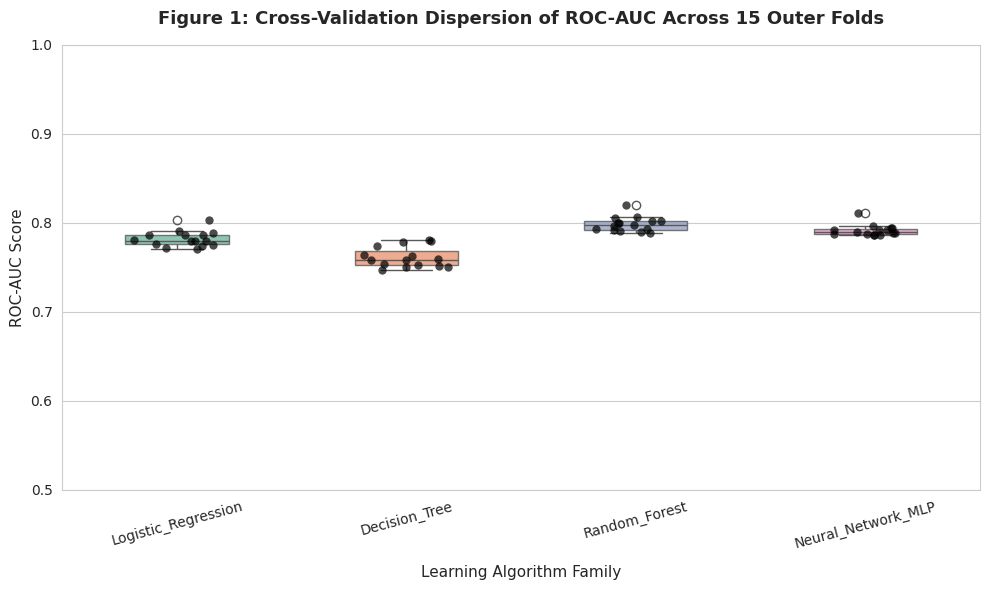

In [26]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=df_raw,
    x='algorithm',
    y='roc_auc',
    palette='Set2',
    width=0.45,
    boxprops=dict(alpha=0.8)
)
sns.stripplot(
    data=df_raw,
    x='algorithm',
    y='roc_auc',
    color='black',
    size=6,
    jitter=0.2,
    alpha=0.7
)

plt.title('Figure 1: Cross-Validation Dispersion of ROC-AUC Across 15 Outer Folds', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Learning Algorithm Family', fontsize=11, labelpad=10)
plt.ylabel('ROC-AUC Score', fontsize=11)
plt.xticks(rotation=15, fontsize=10)
plt.ylim(0.5, 1.0)
plt.tight_layout()

plt.savefig('figure1_dispersion_boxplots.png', dpi=300)
plt.show()

/tmp/ipykernel_1622/680250145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


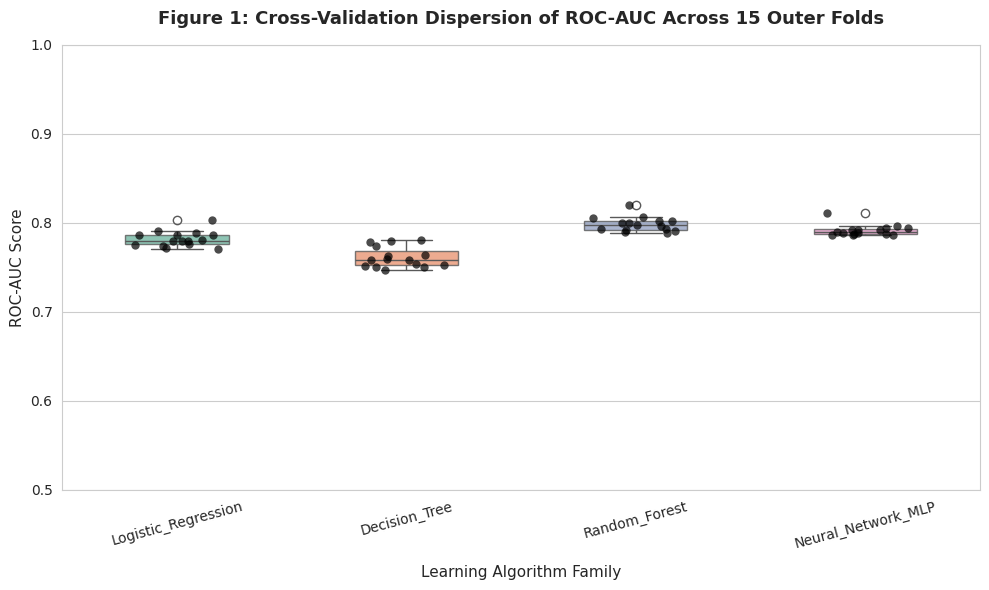

In [29]:
numeric_with_duration = numeric_features + ['duration']
X_with_duration = df[numeric_with_duration + categorical_features]

ablation_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_with_duration),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

ablation_results = []
print("Running Section 5.3 Ablation Study: Impact of 'duration' on Random Forest...")

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_realistic, y)):
    X_tr_leak, X_te_leak = X_with_duration.iloc[train_idx], X_with_duration.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    pipe_leak = Pipeline([
        ('preprocessor', ablation_preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1))
    ])

    pipe_leak.fit(X_tr_leak, y_tr)
    scores_leak = pipe_leak.predict_proba(X_te_leak)[:, 1]
    preds_leak = pipe_leak.predict(X_te_leak)

    auc_leak = roc_auc_score(y_te, scores_leak)
    f1_leak = f1_score(y_te, preds_leak, average='macro')

    ablation_results.append({
        'fold': fold_idx + 1,
        'auc_with_duration': auc_leak,
        'f1_with_duration': f1_leak
    })

df_ablation = pd.DataFrame(ablation_results)
rf_realistic = df_raw[df_raw['algorithm'] == 'Random_Forest']

print("\n" + "=" * 75)
print("             TABLE: SECTION 5.3 ABLATION STUDY SUMMARY                   ")
print("=" * 75)
print(f"Realistic Model (Without duration): ROC-AUC = {rf_realistic['roc_auc'].mean():.4f} ± {rf_realistic['roc_auc'].std():.4f}")
print(f"Leaky Model     (WITH duration):    ROC-AUC = {df_ablation['auc_with_duration'].mean():.4f} ± {df_ablation['auc_with_duration'].std():.4f}")
print(f"Delta ROC-AUC (Leakage Gain):      +{df_ablation['auc_with_duration'].mean() - rf_realistic['roc_auc'].mean():.4f}")
print("=" * 75)

df_ablation.to_csv('table6_ablation_study.csv', index=False)

Running Section 5.3 Ablation Study: Impact of 'duration' on Random Forest...

             TABLE: SECTION 5.3 ABLATION STUDY SUMMARY                   
Realistic Model (Without duration): ROC-AUC = 0.7985 ± 0.0082
Leaky Model     (WITH duration):    ROC-AUC = 0.9430 ± 0.0025
Delta ROC-AUC (Leakage Gain):      +0.1445


FIGURE 2: NORMALIZED CONFUSION MATRICES


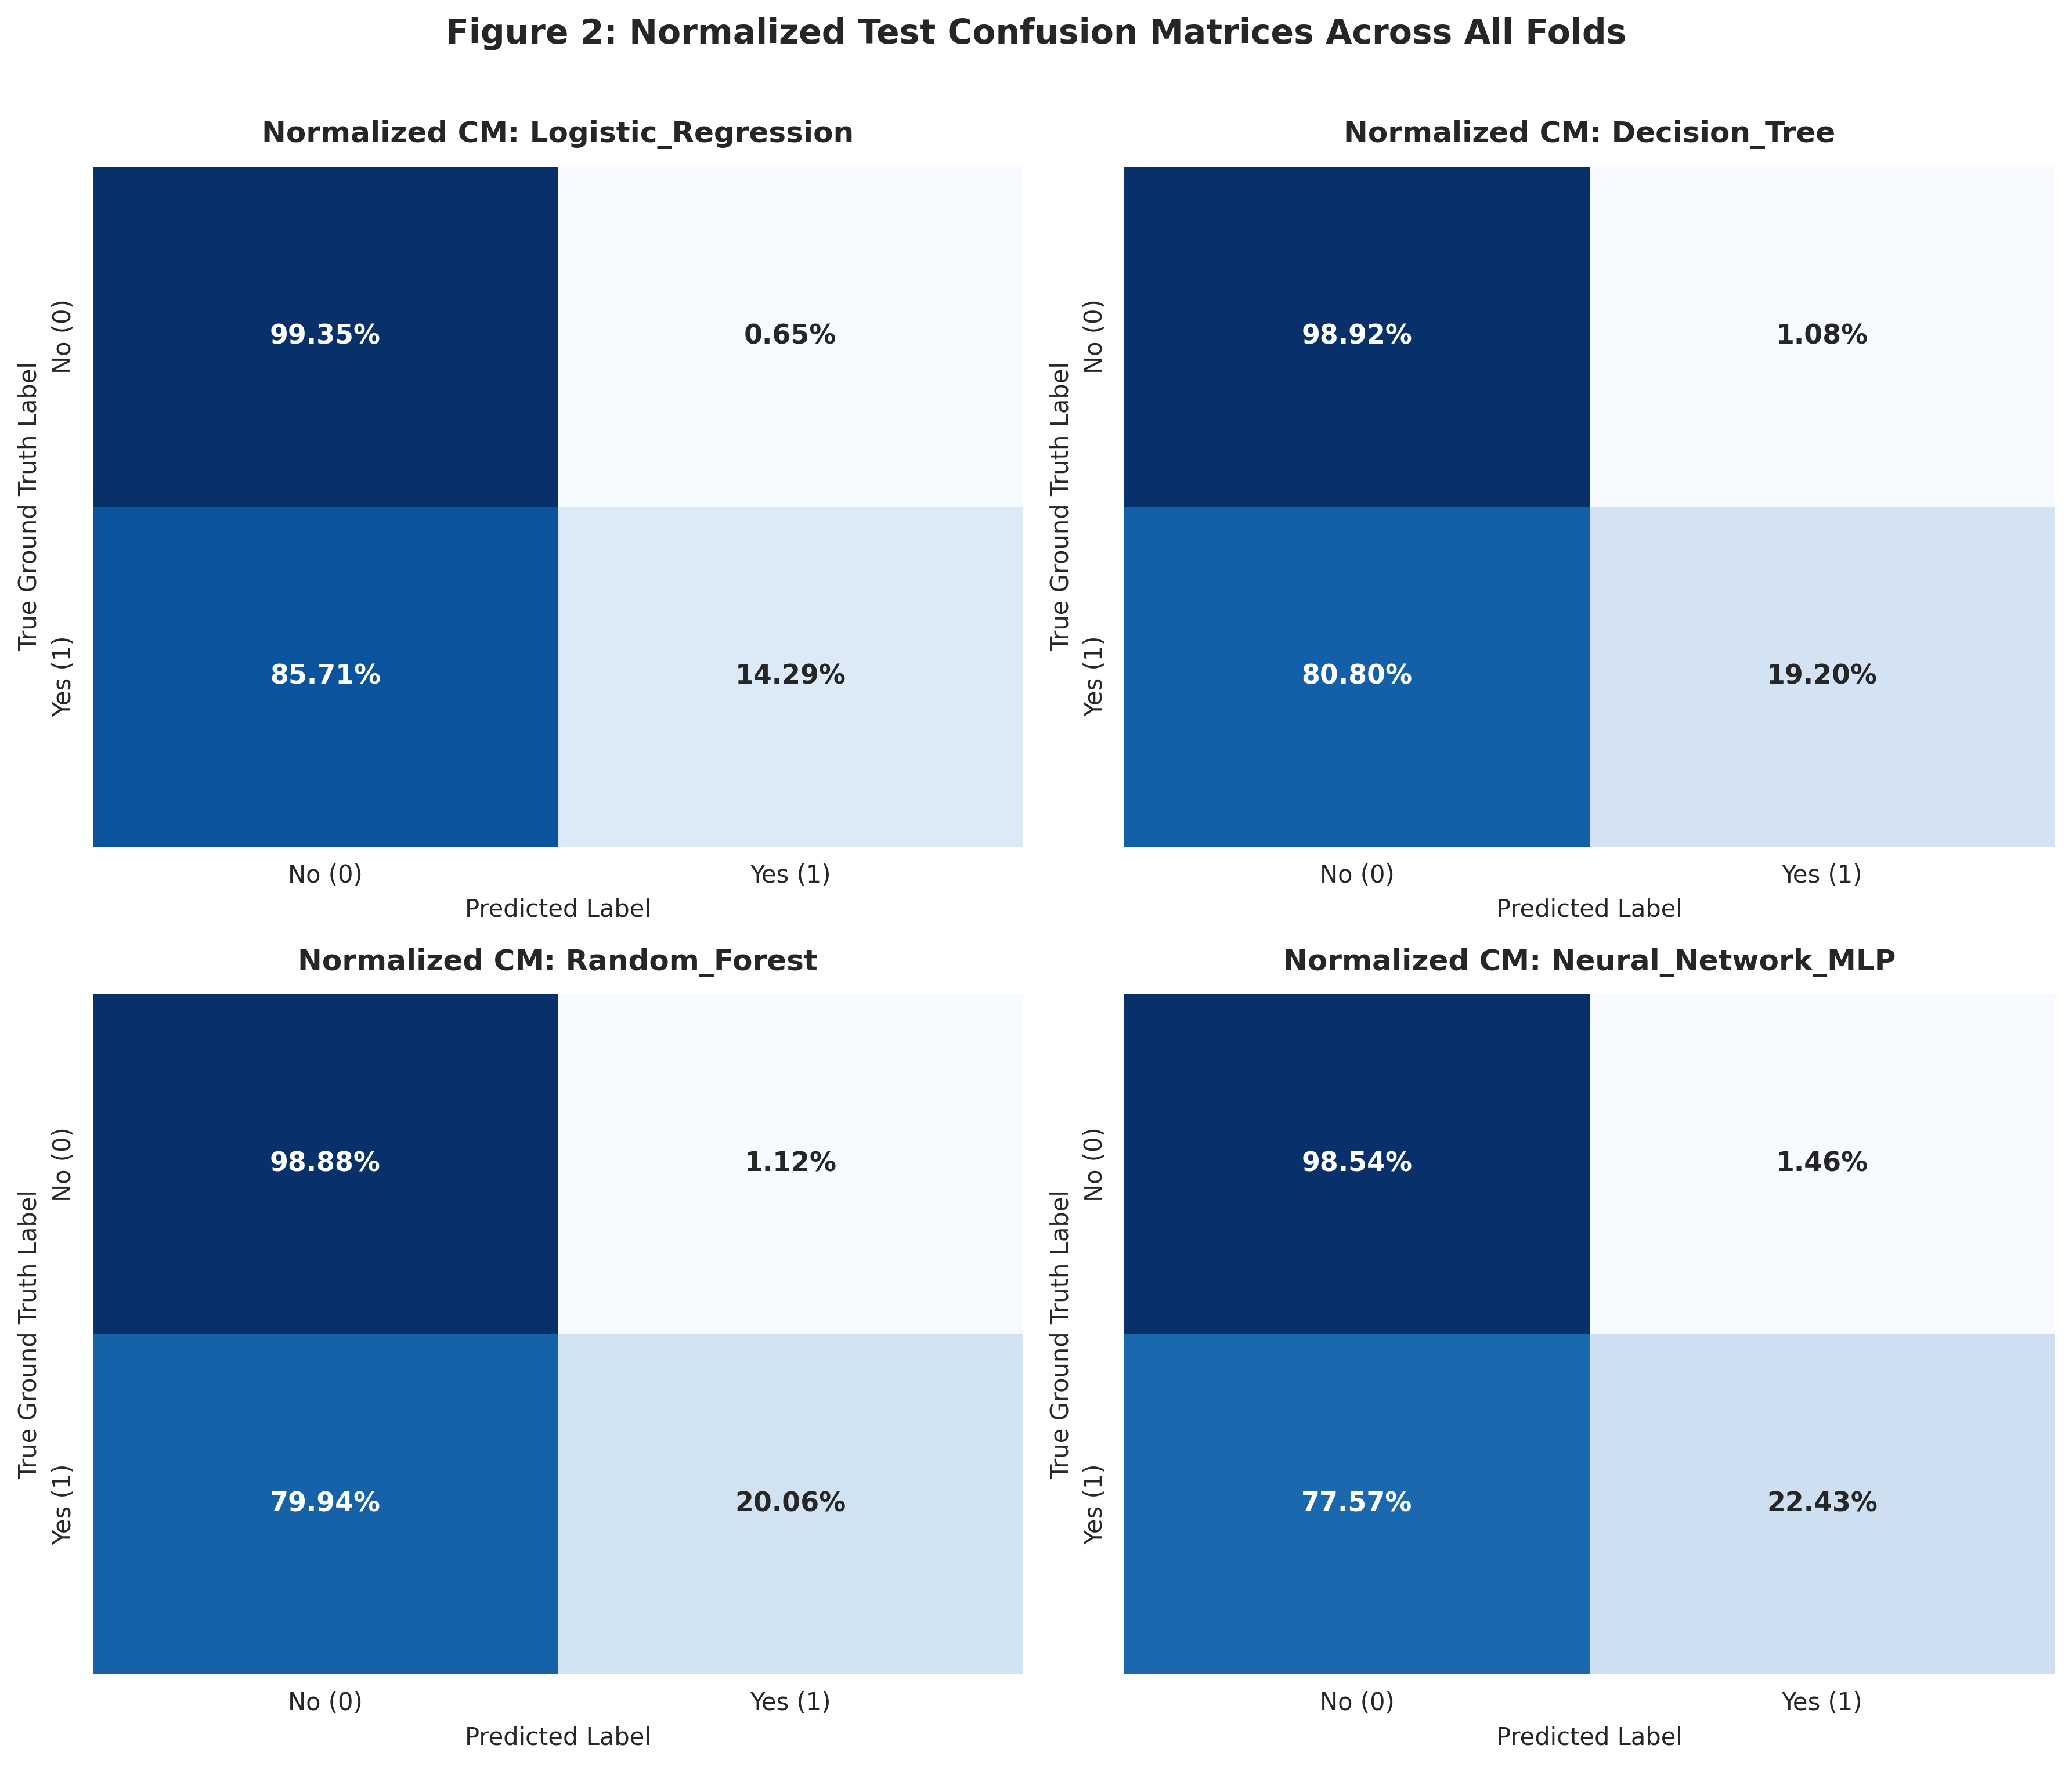

Figure 2 successfully generated and saved to 'figure2_confusion_matrices.png'


In [31]:

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
axes = axes.flatten()

model_names = list(base_models.keys())

for idx, model_name in enumerate(model_names):
    cm = confusion_matrix(
        oof_predictions[model_name]['y_true'],
        oof_predictions[model_name]['y_pred'],
        normalize='true'
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='.2%',
        cmap='Blues',
        cbar=False,
        ax=axes[idx],
        xticklabels=['No (0)', 'Yes (1)'],
        yticklabels=['No (0)', 'Yes (1)'],
        annot_kws={'size': 11, 'weight': 'bold'}
    )

    axes[idx].set_title(f'Normalized CM: {model_name}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Ground Truth Label', fontsize=10)

plt.suptitle('Figure 2: Normalized Test Confusion Matrices Across All Folds', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure2_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Figure 2 successfully generated and saved to 'figure2_confusion_matrices.png'")

In [32]:
pip freeze > requirements.txt